## 실습 과제2: 벡터화 연산과 브로드캐스팅 이해하기

### 문제 1: 기본 벡터화와 브로드캐스팅 이해하기
* x = np.linspace(0, 5, 50)와 y = np.linspace(0, 5, 50)[:, np.newaxis]를 생성하세요. 
* 여기서 x는 (50,)의 1차원 배열이고, y는 [:, np.newaxis]를 사용하여 (50, 1)의 2차원 배열로 변환됩니다.

* x와 y의 형태를 출력하여 브로드캐스팅이 어떻게 이루어지는지 확인하세요.

In [ ]:
import numpy as np

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 50)[:, np.newaxis]

x.shape, y.shape

((50,), (50, 1))

### 문제 2: 브로드캐스팅을 활용하여 수식 계산하기
z = np.sin(x) ** 200 + np.cos(300 + y * x) * np.cos(x)를 사용하여 z 배열을 계산하세요.

z 배열의 형태를 출력하고, 브로드캐스팅에 의해 z의 형태가 (50, 50)이 되었는지 확인하세요.

In [8]:
def f(x, y):
    return np.sin(x)**200 + np.cos(300 + y*x)*np.cos(x)

z = f(x, y)

%timeit f(x, y)

34.8 µs ± 654 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### 문제 3: 벡터화 연산으로 계산 속도 비교하기
for 반복문을 사용해 z의 각 요소를 수동으로 계산하는 코드를 작성하고, 벡터화 연산으로 구한 z와 같은 결과가 나오는지 확인하세요.

timeit 모듈을 사용하여 반복문을 통한 계산과 벡터화 연산을 각각 수행하는 데 걸리는 시간을 측정하고, 두 연산 방식의 속도 차이를 비교하세요.

In [5]:
import math

def f2(x, y):
    result = []
    for i in x:
        for j in y:
            a1 = math.sin(i)**200
            a3 = math.cos(i)
            a2= np.cos(300 + j * i)
            result.append(a1 + a2 * a3)
    return result

len(f2(x, y.flatten()))

%timeit f2(x, y)

9.47 ms ± 88.7 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### 문제 4: 그래프를 사용해 시각적으로 결과 확인하기
z 값을 시각적으로 이해하기 위해 matplotlib 라이브러리를 사용하여 z의 값을 컬러 맵으로 시각화하세요.

plt.imshow(z, extent=(0, 5, 0, 5), origin='lower', cmap='viridis')와 plt.colorbar()를 사용해 결과를 시각화하고, 그래프의 형태를 확인하세요.

C:\Users\user\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


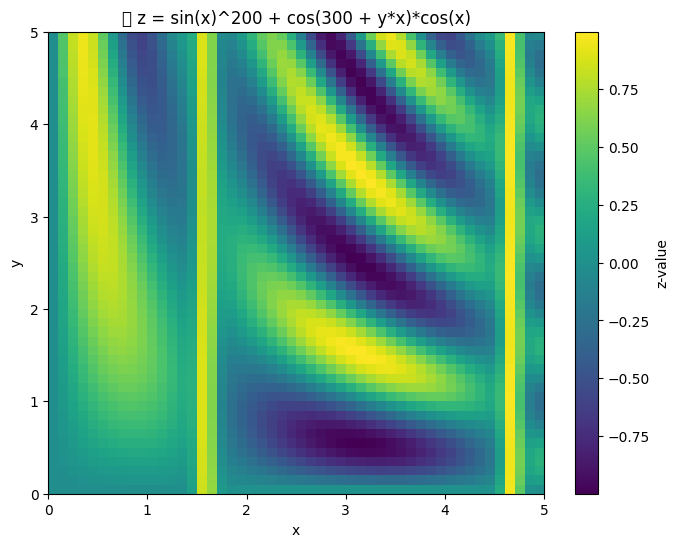

In [10]:
import matplotlib.pyplot as plt

# 1. z 계산
Xi, Yi = np.meshgrid(x, y)
z = f(Xi, Yi)  # f는 벡터화 함수라고 가정

# 2. 시각화
plt.figure(figsize=(8, 6))
plt.imshow(z, extent=(0, 5, 0, 5), origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='z-value')
plt.title("🌈 z = sin(x)^200 + cos(300 + y*x)*cos(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

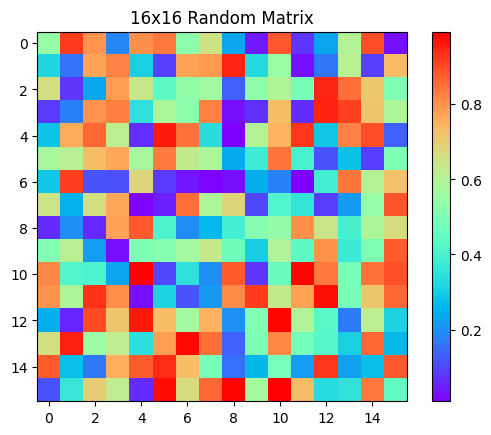

In [25]:
A = np. random.rand(16, 16)

A.shape, A.dtype, A.shape[0], A.ndim, A.size

plt.imshow(A, cmap='rainbow')  # 컬러맵 선택
plt.colorbar()                 # 오른쪽에 색상 범례 표시
plt.title("16x16 Random Matrix")
plt.show()